# Long-Short (Dollar-Neutral) Momentum — two widths, monthly & weekly

Cross-sectional momentum traded **long-short**: each rebalance go **long the high-
momentum names** and **short the low-momentum names** by risk-adjusted 12-1 momentum,
each leg summing to ±1 → **net 0, gross 2×** before vol-targeting (scaled to a **20%
vol target**; gross leverage = 2 × multiplier). Two selection widths, both **monthly
and weekly**:
* **20%** — long top 20% / short bottom 20% (the standard quintile L/S).
* **50%** — long top half / short bottom half (the *full* cross-sectional momentum
  factor; every name is on one side).

The wider the book, the **lower** the long-short spread vol → the **more leverage**
needed to reach 20%. This section reports that leverage and whether the short leg pays.

> **Caveats.** (1) **Borrow / short-financing costs are NOT modelled** — real net
> returns would be lower. (2) Long-short momentum carries **"momentum crash"** tail
> risk (2009). (3) Market-neutral, so the long-only benchmark isn't comparable.
> Outputs in `results/long_short/`.

In [1]:
import warnings, os; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import momentum_strategies as ms
pd.set_option("display.float_format", lambda x: f"{x:,.3f}"); pd.set_option("display.max_columns", 40)
RES = "results/long_short"
for k in ["figures", "figure_data", "metrics", "weights"]: os.makedirs(f"{RES}/{k}", exist_ok=True)

md_m = ms.DataLoader("data").load()
md_w = ms.DataLoader("data", freq="W").load()
cost = ms.RealisticCostModel(fx_bps=15.0, aum=1e8)
MAXLEV = 3.0        # multiplier cap -> gross capped at 2 x 3 = 6x

def ls_cfg(ppy, top_pct):
    return ms.StrategyConfig(kind="ls", top_pct=top_pct, weighting="equal", target_vol=0.20,
        max_leverage=MAXLEV,
        lookback=52 if ppy == 52 else 12, gap=4 if ppy == 52 else 1,
        vol_window=52 if ppy == 52 else None,
        vol_lookback=26 if ppy == 52 else 6, vol_halflife=17.0 if ppy == 52 else 4.0)

variants = {
    "monthly 20%": (md_m, 12, ls_cfg(12, 0.20)), "monthly 50%": (md_m, 12, ls_cfg(12, 0.50)),
    "weekly 20%":  (md_w, 52, ls_cfg(52, 0.20)), "weekly 50%":  (md_w, 52, ls_cfg(52, 0.50)),
}
print("variants:", list(variants))

variants: ['monthly 20%', 'monthly 50%', 'weekly 20%', 'weekly 50%']


## 1. Construction check — net ≈ 0

Current book sizes for the monthly variants: the 50% book puts *every* name on one
side (long top half, short bottom half); the 20% book holds only the quintile tails.
Both net to ~0.

In [2]:
for nm in ["monthly 20%", "monthly 50%"]:
    mkt, ppy, cfg = variants[nm]
    res = ms.Backtester(mkt, cost, ppy).run(ms.build_signal(mkt, cfg), cfg)
    cur = res.current_weights()
    print("%-12s: %d long, %d short | net %.3f | gross %.2fx" % (
        nm, (cur > 0).sum(), (cur < 0).sum(), cur.sum(), cur.abs().sum()))

monthly 20% : 96 long, 96 short | net 0.000 | gross 2.49x


monthly 50% : 239 long, 239 short | net 0.000 | gross 3.99x


## 2. Statistics & leverage (the headline)

**Gross leverage** = mean / max of |long| + |short| (net ≈ 0). **Unlevered vol** is
the raw gross-2 book's vol — the gap to 20% is what the leverage closes. Watch how the
wider 50% book needs more leverage (lower spread vol).

In [3]:
results, rows = {}, {}
for nm, (mkt, ppy, cfg) in variants.items():
    res = ms.Backtester(mkt, cost, ppy).run(ms.build_signal(mkt, cfg), cfg)
    results[nm] = res
    ms.save_weights(res, f"{RES}/weights/{nm.replace(' ', '_').replace('%', 'pct')}", sectors=mkt.sectors)
    m = ms.metrics_from_result(res)
    base = ms.compute_metrics(res.base_returns, periods_per_year=res.periods_per_year)
    rows[nm] = {"Sharpe": m["Sharpe"], "Sortino": m["Sortino"], "CAGR": m["CAGR"], "Ann.Vol": m["Ann.Vol"],
                "MaxDrawdown": m["MaxDrawdown"], "Calmar": m["Calmar"], "WinRate": m["WinRate"],
                "ProfitFactor": m["ProfitFactor"], "AnnTurnover": m["AnnTurnover"], "AnnTCost": m["AnnTCost"],
                "GrossLev(mean)": res.leverage.mean(), "GrossLev(max)": res.leverage.max(),
                "NetExposure": res.weights.sum(axis=1).mean(), "UnlevVol": base["Ann.Vol"]}
tbl = pd.DataFrame(rows); tbl.to_csv(f"{RES}/metrics/long_short_metrics.csv")
print("Long-short momentum — 20% vs 50% width, monthly & weekly (net of FX/spread/impact; borrow NOT modelled):")
display(tbl.round(3))

Long-short momentum — 20% vs 50% width, monthly & weekly (net of FX/spread/impact; borrow NOT modelled):


,monthly 20%,monthly 50%,weekly 20%,weekly 50%
Sharpe,-0.015,-0.025,0.242,0.385
Sortino,-0.021,-0.035,0.298,0.515
CAGR,-0.023,-0.022,0.028,0.053
Ann.Vol,0.202,0.188,0.194,0.173
MaxDrawdown,-0.678,-0.682,-0.262,-0.200
Calmar,-0.034,-0.033,0.108,0.265
WinRate,0.478,0.478,0.394,0.378
ProfitFactor,0.988,0.980,1.108,1.184
AnnTurnover,10.379,10.528,17.902,17.286
AnnTCost,0.039,0.040,0.063,0.061


## 3. Leverage through time & growth of \$1

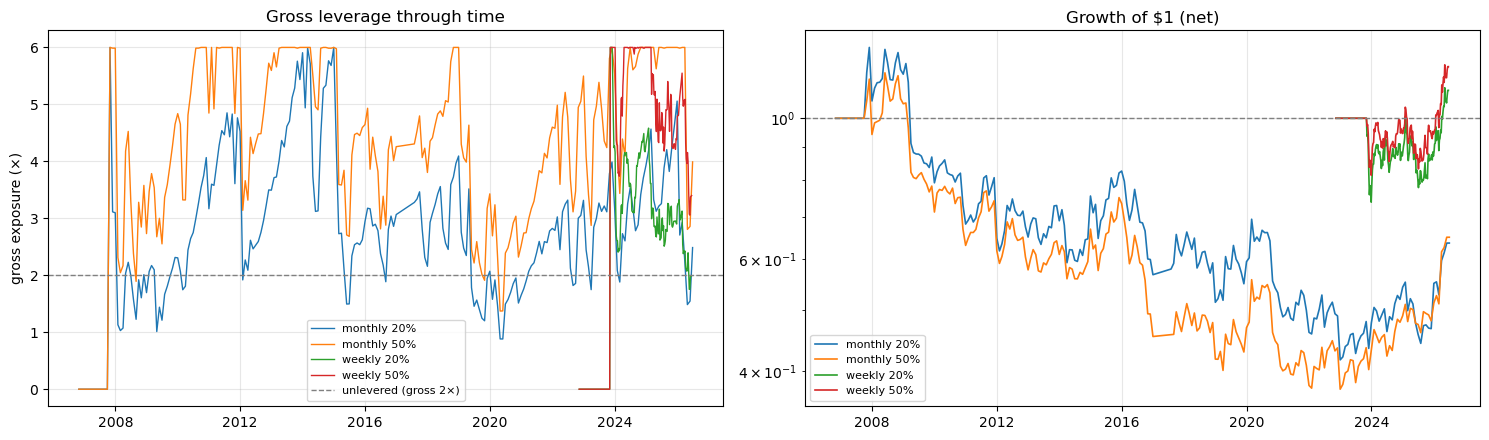

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for nm, res in results.items():
    ax[0].plot(res.leverage.index, res.leverage.values, label=nm, lw=1.0)
    eq = res.equity("net"); ax[1].plot(eq.index, eq.values, label=nm, lw=1.2)
ax[0].axhline(2.0, ls="--", color="grey", lw=1, label="unlevered (gross 2×)")
ax[0].set_title("Gross leverage through time"); ax[0].set_ylabel("gross exposure (×)"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].axhline(1.0, ls="--", color="grey", lw=1); ax[1].set_yscale("log")
ax[1].set_title("Growth of $1 (net)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
pd.DataFrame({nm: res.leverage for nm, res in results.items()}).to_csv(f"{RES}/figure_data/leverage.csv")
pd.DataFrame({nm: res.equity("net") for nm, res in results.items()}).to_csv(f"{RES}/figure_data/growth.csv")
fig.savefig(f"{RES}/figures/leverage_and_growth.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 4. Target volatility → leverage

The vol-target sets the book size: gross leverage ≈ `target_vol / spread_vol`, so it scales
**~linearly** with the target — until the **6× gross cap** binds (the 50% book saturates ~4–5×
and can no longer reach a 30% vol target). Net Sharpe is *not* perfectly scale-invariant on this
short sample: costs scale with leverage, so the **monthly** book (≈0 gross edge) looks best
**barely levered** (costs eat the rest), while the **weekly** book earns more the **more** it's
levered. So the target-vol choice is really a cost/turnover trade-off, not a free Sharpe lever.

Mean GROSS leverage vs target vol (gross cap = 2 x MAXLEV = 6x):


variant,monthly 20%,monthly 50%,weekly 20%,weekly 50%
target_vol,,,,
0.050,0.720,1.180,0.650,1.080
0.100,1.410,2.330,1.260,2.060
0.150,2.100,3.440,1.840,3.020
0.200,2.790,4.280,2.410,3.750
0.250,3.430,4.870,2.980,4.170
0.300,3.970,5.210,3.480,4.310


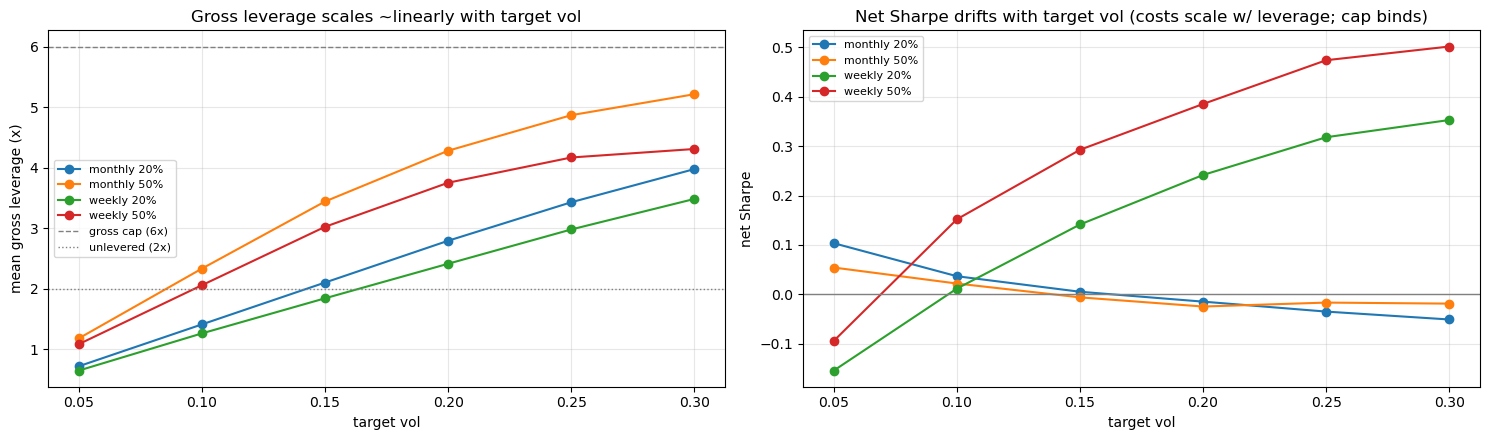

In [5]:
# Sweep the vol target for every variant -> mean/max gross leverage, realized vol, net Sharpe
tgt_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
lev_rows = []
for nm, (mkt, ppy, base) in variants.items():
    sig = ms.build_signal(mkt, base)
    for tv in tgt_grid:
        cfg = ms.StrategyConfig(**{**base.__dict__, "target_vol": tv})
        res = ms.Backtester(mkt, cost, ppy).run(sig, cfg)
        m = ms.metrics_from_result(res)
        lev_rows.append({"variant": nm, "target_vol": tv, "gross_lev_mean": res.leverage.mean(),
                         "gross_lev_max": res.leverage.max(), "real_vol": m["Ann.Vol"], "net_sharpe": m["Sharpe"]})
lev = pd.DataFrame(lev_rows); lev.to_csv(f"{RES}/figure_data/target_vol_leverage.csv", index=False)
print("Mean GROSS leverage vs target vol (gross cap = 2 x MAXLEV = %.0fx):" % (2 * MAXLEV))
display(lev.pivot(index="target_vol", columns="variant", values="gross_lev_mean")[list(variants)].round(2))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for nm in variants:
    d = lev[lev.variant == nm]
    ax[0].plot(d.target_vol, d.gross_lev_mean, "o-", label=nm)
    ax[1].plot(d.target_vol, d.net_sharpe, "o-", label=nm)
ax[0].axhline(2 * MAXLEV, ls="--", color="grey", lw=1, label=f"gross cap ({2*MAXLEV:.0f}x)")
ax[0].axhline(2.0, ls=":", color="grey", lw=1, label="unlevered (2x)")
ax[0].set(xlabel="target vol", ylabel="mean gross leverage (x)", title="Gross leverage scales ~linearly with target vol")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].axhline(0, color="grey", lw=1)
ax[1].set(xlabel="target vol", ylabel="net Sharpe", title="Net Sharpe drifts with target vol (costs scale w/ leverage; cap binds)")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.savefig(f"{RES}/figures/target_vol_leverage.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 5. Capacity

How large can each book get before market impact eats the edge? We sweep AUM with the **realistic
cost model** (FX 15bps + vol-scaled spread + Almgren square-root impact) — impact is charged on the
**levered** notional (both legs, ~2–4× gross), so the L/S book hits impact sooner than a long-only
book of the same AUM. Capacity is where **net Sharpe rolls over** / cost drag overwhelms the (thin) edge.

Net Sharpe vs AUM (realistic costs; impact on the ~2-4x levered notional):


variant,monthly 20%,monthly 50%,weekly 20%,weekly 50%
aum,,,,
"10,000,000.000",-0.000,-0.008,0.252,0.395
"30,000,000.000",-0.005,-0.014,0.248,0.392
"100,000,000.000",-0.015,-0.025,0.242,0.385
"300,000,000.000",-0.030,-0.042,0.231,0.375
"1,000,000,000.000",-0.058,-0.073,0.210,0.355
"3,000,000,000.000",-0.090,-0.107,0.177,0.322
"10,000,000,000.000",-0.123,-0.144,0.114,0.260
"30,000,000,000.000",-0.148,-0.172,0.043,0.189
"100,000,000,000.000",-0.164,-0.191,-0.015,0.131



Annual cost drag (%/yr) vs AUM:


variant,monthly 20%,monthly 50%,weekly 20%,weekly 50%
aum,,,,
"10,000,000.000",3.650,3.740,6.120,5.900
"30,000,000.000",3.750,3.840,6.190,5.960
"100,000,000.000",3.950,4.040,6.310,6.070
"300,000,000.000",4.260,4.370,6.520,6.250
"1,000,000,000.000",4.810,4.950,6.920,6.590
"3,000,000,000.000",5.460,5.600,7.560,7.150
"10,000,000,000.000",6.130,6.290,8.770,8.230
"30,000,000,000.000",6.630,6.820,10.160,9.460
"100,000,000,000.000",6.950,7.190,11.280,10.470


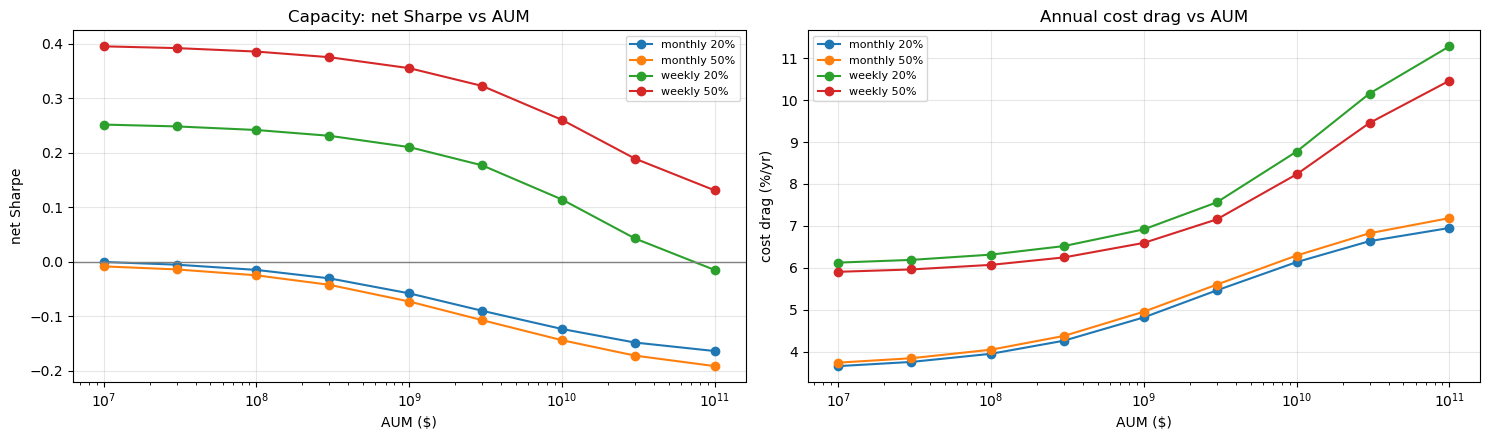

In [6]:
# Capacity: net Sharpe & cost drag vs AUM (realistic FX + spread + sqrt-impact on the levered book)
aum_grid = [1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10, 3e10, 1e11]
cap_rows = []
for nm, (mkt, ppy, cfg) in variants.items():
    sig = ms.build_signal(mkt, cfg)
    for aum in aum_grid:
        res = ms.Backtester(mkt, ms.RealisticCostModel(fx_bps=15.0, aum=aum), ppy).run(sig, cfg)
        m = ms.metrics_from_result(res)
        cap_rows.append({"variant": nm, "aum": aum, "net_sharpe": m["Sharpe"],
                         "net_cagr": m["CAGR"], "ann_tcost": m["AnnTCost"]})
cap = pd.DataFrame(cap_rows); cap.to_csv(f"{RES}/figure_data/capacity.csv", index=False)
print("Net Sharpe vs AUM (realistic costs; impact on the ~2-4x levered notional):")
display(cap.pivot(index="aum", columns="variant", values="net_sharpe")[list(variants)].round(3))
print("\nAnnual cost drag (%/yr) vs AUM:")
display((100 * cap.pivot(index="aum", columns="variant", values="ann_tcost")[list(variants)]).round(2))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for nm in variants:
    d = cap[cap.variant == nm]
    ax[0].plot(d.aum, d.net_sharpe, "o-", label=nm)
    ax[1].plot(d.aum, 100 * d.ann_tcost, "o-", label=nm)
ax[0].axhline(0, color="grey", lw=1); ax[0].set_xscale("log")
ax[0].set(xlabel="AUM ($)", ylabel="net Sharpe", title="Capacity: net Sharpe vs AUM"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].set_xscale("log")
ax[1].set(xlabel="AUM ($)", ylabel="cost drag (%/yr)", title="Annual cost drag vs AUM"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.savefig(f"{RES}/figures/capacity.png", dpi=120, bbox_inches="tight"); plt.tight_layout(); plt.show()

## 6. Dashboard — monthly 20%

2×3 dashboard for the monthly 20% book (benchmark panel = long-only index, reference
only — this is market-neutral). The drawdown panel exposes the **2009 momentum crash**.

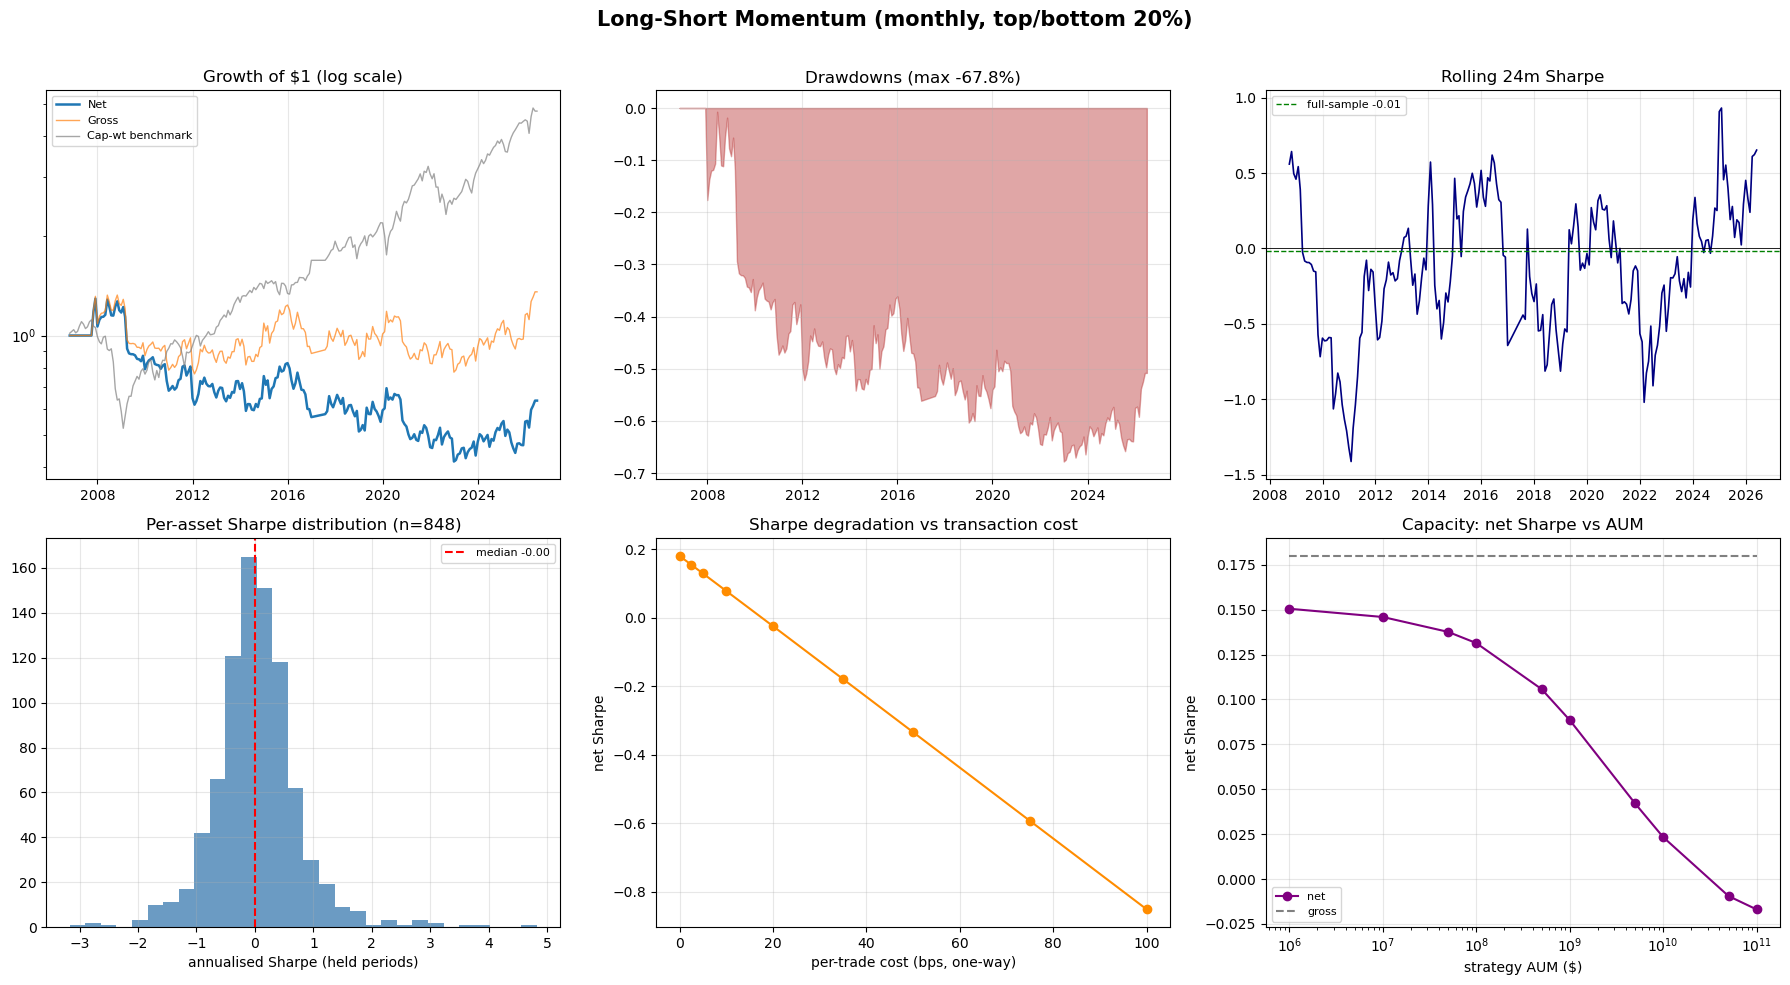

In [7]:
sig_m = ms.build_signal(md_m, variants["monthly 20%"][2])
ms.plot_strategy_dashboard(results["monthly 20%"], md_m, sig_m,
    "Long-Short Momentum (monthly, top/bottom 20%)",
    fig_path=f"{RES}/figures/ls_monthly_dashboard.png", data_dir=f"{RES}/figure_data",
    slug="ls_monthly"); plt.show()

## 7. Conclusions

* **Leverage scales with width.** Dollar-neutral (net ≈ 0). The **wider 50% book has
  the lowest spread vol** → it needs the **most** leverage (often pinned at the 6× cap)
  and may not even reach 20% vol; the **20% book** runs ~2.4–2.8× gross. Concentrating
  raises spread vol and lowers the leverage needed.
* **Performance.** The short leg does **not** earn its keep in S&P large-caps at either
  width: **monthly** long-short is roughly **flat-to-negative** with a **catastrophic
  ~−60–70% drawdown** from the 2009 momentum crash, plus **~4–6%/yr cost drag** (both
  legs, levered) before borrow fees. **Weekly** (short 2022-11+ sample) is mildly
  positive but weak.
* **Bottom line.** Long-short momentum here is a **levered, crash-prone, ~zero-edge**
  book regardless of width; the long-only / trend-filtered books remain the better
  expression of the signal.
* **Target vol is a leverage/cost dial, not a Sharpe dial.** Gross leverage scales ~linearly
  with the target — at **10%** the books run **~1.3–2.3×** (half of the 20% figures), at **20%**
  **~2.4–4.3×**, saturating near the 6× cap by 30% (the 50% book can't even reach 30% vol).
  Because cost scales with leverage, the (flat) monthly book is least-bad barely levered and the
  weekly book improves with leverage — pick the target for the turnover/cost you'll tolerate.
* **Capacity is large (these are S&P mega-caps) — the edge, not impact, is the binding
  constraint.** Net Sharpe barely moves from \$10M to ~\$1B; impact only bites in the **tens of
  billions**. The **weekly 50%** book keeps ~half its Sharpe out to **~\$30B** (still +0.13 at
  \$100B); **weekly 20%** to **~\$5–10B**. The **monthly** books are ≤0 at *every* size — no
  capacity because there's no edge to scale. Cost drag climbs from ~4%/yr (monthly) / ~6%/yr
  (weekly) at small size to ~7% / ~11% at \$100B, before any borrow fee.